In [99]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Source: https://github.com/alexeygrigorev/mlbookcamp-code/tree/master/chapter-02-car-price
df=pd.read_csv('data.csv')
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


### Data cleaning

In [101]:
#Cleaning column headings
print(df.columns)
df.columns=df.columns.str.lower().str.replace(' ','_')
df.head()

Index(['Make', 'Model', 'Year', 'Engine Fuel Type', 'Engine HP',
       'Engine Cylinders', 'Transmission Type', 'Driven_Wheels',
       'Number of Doors', 'Market Category', 'Vehicle Size', 'Vehicle Style',
       'highway MPG', 'city mpg', 'Popularity', 'MSRP'],
      dtype='str')


,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [102]:
#Cleaning data. But not all data are strings. Cleaning only columns with strings
str_columns=list(df.columns[df.dtypes == 'str'])
for col in str_columns:
    df[col]=df[col].str.lower().str.replace(' ','_')
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500


In [103]:
for col in df.columns:
    print(col)
    print('------------')
    print("Unique entries", df[col].unique()[:5])
    print('count of unique', df[col].nunique())

make
------------
Unique entries <StringArray>
['bmw', 'audi', 'fiat', 'mercedes-benz', 'chrysler']
Length: 5, dtype: str
count of unique 48
model
------------
Unique entries <StringArray>
['1_series_m', '1_series', '100', '124_spider', '190-class']
Length: 5, dtype: str
count of unique 914
year
------------
Unique entries [2011 2012 2013 1992 1993]
count of unique 28
engine_fuel_type
------------
Unique entries <StringArray>
[   'premium_unleaded_(required)',               'regular_unleaded',
 'premium_unleaded_(recommended)',       'flex-fuel_(unleaded/e85)',
                         'diesel']
Length: 5, dtype: str
count of unique 10
engine_hp
------------
Unique entries [335. 300. 230. 320. 172.]
count of unique 356
engine_cylinders
------------
Unique entries [ 6.  4.  5.  8. 12.]
count of unique 9
transmission_type
------------
Unique entries <StringArray>
['manual', 'automatic', 'automated_manual', 'direct_drive', 'unknown']
Length: 5, dtype: str
count of unique 5
driven_wheels
-

count    1.191400e+04
mean     4.059474e+04
std      6.010910e+04
min      2.000000e+03
25%      2.100000e+04
50%      2.999500e+04
75%      4.223125e+04
max      2.065902e+06
Name: msrp, dtype: float64


<Axes: xlabel='msrp', ylabel='Count'>

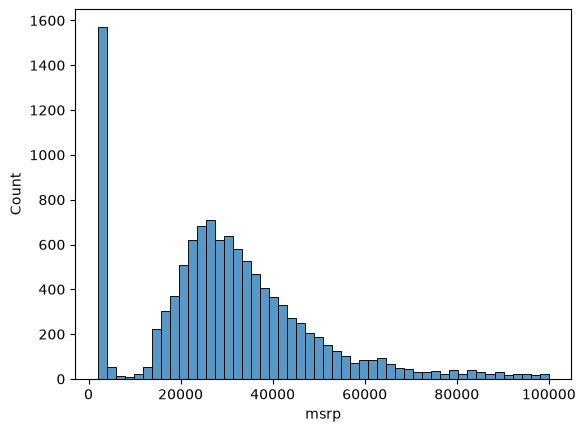

In [104]:
print(df['msrp'].describe())
sns.histplot(df.msrp[df['msrp']<100000], bins=50)

<Axes: xlabel='msrp', ylabel='Count'>

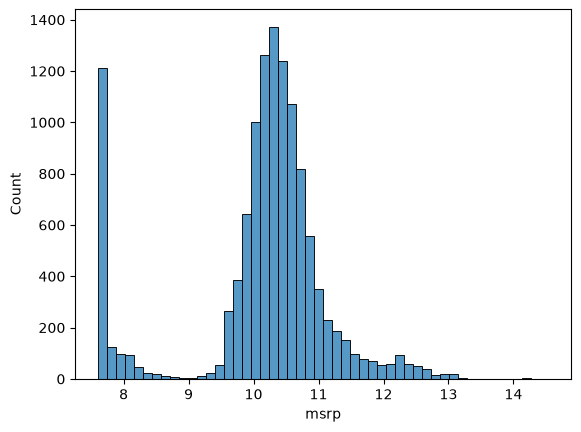

In [105]:
#Data transformation
price_logs=np.log1p(df.msrp)
sns.histplot(price_logs,bins=50)

In [106]:
df.isnull().sum()
#20% of df for validation and test. Rest is training
n=len(df)
n_val=int(n*0.2)
n_test=int(n*0.2)
n_train=n-n_val-n_test
n_train, n_val, n_test

(7150, 2382, 2382)

In [107]:
#dataframe shuffling
idx=np.arange(n)
np.random.seed(2)
np.random.shuffle(idx)
df_train=df.iloc[idx[:n_train]]
df_val=df.iloc[idx[n_train:n_train+n_val]]
df_test=df.iloc[idx[n_train+n_val:]]

In [108]:
df_train=df_train.reset_index(drop=True)
df_val=df_val.reset_index(drop=True)
df_test=df_test.reset_index(drop=True)
len(df_train),len(df_val),len(df_test)
df_train

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385,14410
1,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031,19685
2,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640,19795
3,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873,2000
4,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657,56260
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7145,bmw,4_series,2015,premium_unleaded_(required),300.0,6.0,automatic,rear_wheel_drive,2.0,"luxury,performance",midsize,convertible,31,20,3916,54900
7146,volkswagen,beetle,2015,premium_unleaded_(recommended),210.0,4.0,automated_manual,front_wheel_drive,2.0,"hatchback,performance",compact,2dr_hatchback,30,24,873,29215
7147,gmc,sierra_1500,2015,flex-fuel_(unleaded/e85),285.0,6.0,automatic,four_wheel_drive,4.0,flex_fuel,large,extended_cab_pickup,22,17,549,34675
7148,rolls-royce,ghost,2014,premium_unleaded_(required),563.0,12.0,automatic,rear_wheel_drive,4.0,"exotic,luxury,performance",large,sedan,21,13,86,303300


In [109]:
#value vector
y_train=np.log1p(df_train['msrp'].values)
y_val=np.log1p(df_val['msrp'].values)
y_test=np.log1p(df_test['msrp'].values)

In [110]:
del(df_train['msrp'])
del(df_val['msrp'])
del(df_test['msrp'])

# Linear Regression

In [111]:
#Simple linear regression
df_train.iloc[10] #only considering for this example
xi=[453,11,86]
w0=7.17
w=[0.01,0.04,0.002]
def linear_regression(xi):
    n=len(xi)
    pred=w0
    for j in range(n):
        pred=pred+w[j]*xi[j]
    return pred

linear_regression(xi)
# but the msrp values are transformed log(1+x). So reverse it
np.expm1(linear_regression(xi))

np.float64(222347.2221101062)

In [112]:
#Implementation of linear regression with more examples. The bias w0 is integrated into w vector by adding [1] column to X. This makes linear regression as just dot product instead of addition & dot product.
w_new=[w0] + w
x1  = [1, 148, 24, 1385]
x2  = [1, 132, 25, 2031]
x10 = [1, 453, 11, 86]
X=np.array([x1,x2,x10])
def linear_regression(X):
    return X.dot(w_new)

linear_regression(X)


array([12.38 , 13.552, 12.312])

In [113]:
X = np.array([
    [148, 24, 1385],
    [132, 25, 2031],
    [453, 11, 86],
    [158, 24, 185],
    [172, 25, 201],
    [413, 11, 86],
    [38,  54, 185],
    [142, 25, 431],
    [453, 31, 86],
])
y = [100, 200, 150, 250, 100, 200, 150, 250, 120]
XTX=X.T.dot(X)
XTX_inv=np.linalg.inv(XTX)
w=XTX_inv.dot(X.T).dot(y)

In [114]:
#putting 1 column to X
ones=np.ones(X.shape[0])
X=np.column_stack([ones,X])
XTX=X.T.dot(X)
XTX_inv=np.linalg.inv(XTX)
w_full=XTX_inv.dot(X.T).dot(y)



In [115]:
w_full[0] #bias
w_full[1:] #feature weights

array([-0.22774253, -2.5769413 , -0.02301206])

# model training

In [116]:
#final function for training using car dataset
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [117]:
#baseline prediction
base = ['engine_hp', 'engine_cylinders', 'highway_mpg',
        'city_mpg', 'popularity']
X_train=df_train[base].values
X_train=df_train[base].fillna(0).values
w0, w = train_linear_regression(X_train,y_train)
y_pred = w0 + X_train.dot(w)
print(w0, w, y_pred)

7.927257388069986 [ 9.70589522e-03 -1.59103494e-01  1.43792133e-02  1.49441072e-02
 -9.06908672e-06] [ 9.54792783  9.38733977  9.67197758 ... 10.30423015 11.9778914
  9.99863111]


In [118]:
y_train.shape

(7150,)

<Axes: ylabel='Count'>

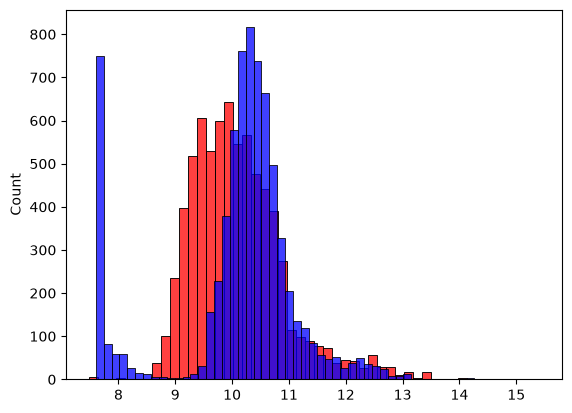

In [119]:
sns.histplot(y_pred, color='red',bins=50)
sns.histplot(y_train, color='blue',bins=50)
#The prediction values are smaller than the actual car price

# RMSE

In [120]:
#finding the rmse
def rmse(y,y_pred): #y=y_train or the target values
    se= (y - y_pred)**2
    mse=se.mean()
    return np.sqrt(mse)

rmse(y_train, y_pred)

np.float64(0.7554192603920132)

# predicting and computing RMSE using validation dataset

In [121]:
# previously, we trained the model on X_train, and got the weights. We also used X_train to predict and find RMSE. \
# Now, we will predict on X_val using weights learnt from X_train, and find RMSE on X_val.
def prepare_X(df): #function to prepare any input df, by taking feature columns, and replacing nan entries.
    df_num=df[base]
    df_num=df_num.fillna(0)
    X=df_num.values
    return X

#applying preparation
X_train=prepare_X(df_train)
w0,w= train_linear_regression(X_train, y_train)

X_val=prepare_X(df_val)
y_pred= w0 + X_val.dot(w)
rmse(y_val,y_pred)
#the values of RMSE using X_train and X_val are similar, showing that model is good.


np.float64(0.761653099130156)

# Simple feature engineering

In [122]:
def prepare_X(df): #function to prepare any input df, by taking feature columns, and replacing nan entries. Now adding the car age.
    df=df.copy()
    df['age']=df['year'].max() - df['year']
    features= base + ['age']
    df_num=df[features]
    df_num=df_num.fillna(0)
    X=df_num.values
    return X

In [123]:
X_train=prepare_X(df_train)

X_train=prepare_X(df_train)
w0,w= train_linear_regression(X_train, y_train)

X_val=prepare_X(df_val)
y_pred= w0 + X_val.dot(w)
rmse(y_val,y_pred)

np.float64(0.5172055461058299)

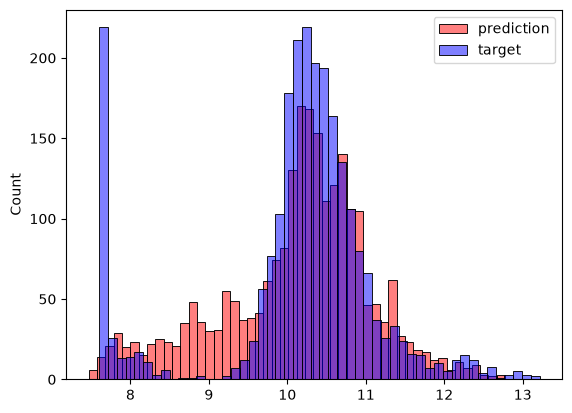

In [124]:
sns.histplot(y_pred, label='prediction', color='red', alpha=0.5, bins=50)
sns.histplot(y_val, label='target', color='blue',  alpha=0.5, bins=50)
plt.legend()
#The shape of the plots are more comparable. But there are still places for improvements

# Categorical values

In [125]:
#No. of doors added to feature list
def prepare_X(df):
    df = df.copy()
    features = base.copy()

    df['age'] = df['year'].max() - df.year
    features.append('age')

    for v in [2, 3, 4]: #for no. of doors
        df['num_doors_%s' % v] = (df.number_of_doors == v).astype('int')
        features.append('num_doors_%s' % v)

    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [126]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred)
#negligible model improvement

np.float64(0.515799564150169)

In [127]:
# Adding make of the car to feature list
makes=list(df_train.make.value_counts().head().index)

def prepare_X(df):
    df = df.copy()
    features = base.copy()

    df['age'] = df['year'].max() - df.year
    features.append('age')

    for v in [2, 3, 4]: #for no. of doors
        df['num_doors_%s' % v] = (df.number_of_doors == v).astype('int')
        features.append('num_doors_%s' % v)

    for v in makes:
        df['make_%s' % v] = (df.make == v).astype('int')
        features.append('make_%s' % v)

    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [128]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred)

np.float64(0.5076038849556795)

In [129]:
#Incorporating all categorical values
categorical_variables = [
    'make', 'engine_fuel_type', 'transmission_type', 'driven_wheels',
    'market_category', 'vehicle_size', 'vehicle_style'
]

categories = {}

for c in categorical_variables:
    categories[c] = list(df_train[c].value_counts().head().index)

In [130]:
#Incorporating all categorical values
def prepare_X(df):
    df = df.copy()
    features = base.copy()

    df['age'] = df['year'].max() - df.year
    features.append('age')

    for v in [2, 3, 4]: #for no. of doors
        df['num_doors_%s' % v] = (df.number_of_doors == v).astype('int')
        features.append('num_doors_%s' % v)

    """for v in makes:
        df['make_%s' % v] = (df.make == v).astype('int')
        features.append('make_%s' % v)"""

    for c, values in categories.items():
        for v in values:
            df['%s_%s' % (c, v)] = (df[c] == v).astype('int')
            features.append('%s_%s' % (c, v))

    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [131]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred)

np.float64(18.231658052676632)

# Regularization

In [ ]:
#Regularization is useful for matrices which are not invertible. Also, it improves the model performance.
def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [134]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression_reg(X_train, y_train,r=0.01)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred)

np.float64(0.456521990159498)

# Tuning the model

In [ ]:
#chossing a right r value
for r in [0, 0.00001, 0.0001, 0.001, 0.1, 1, 10]:
    X_train = prepare_X(df_train)
    w0, w = train_linear_regression_reg(X_train, y_train,r)

    X_val = prepare_X(df_val)
    y_pred = w0 + X_val.dot(w)
    score = rmse(y_val, y_pred)
    print(r, w0, score)

    #r=0.001 gives a good score. So, we can choose this.

0 1490771050477478.8 18.231658052676632
1e-05 3.3018558489965324 0.456517033264953
0.0001 6.336852827878064 0.4565170658328044
0.001 6.285637034753571 0.4565175085263347
0.1 6.191208619220593 0.45656927629982347
1 5.63489666798207 0.4572204317993079
10 4.283980108964412 0.47014569320989463


# Using the model

In [137]:
df_full_train= pd.concat([df_train, df_val])
df_full_train=df_full_train.reset_index(drop=True)


In [140]:
X_full_train=prepare_X(df_full_train)
y_full_train=np.concat([y_train,y_val])

w0, w = train_linear_regression_reg(X_full_train, y_full_train,r=0.001)

X_test = prepare_X(df_test)
y_pred = w0 + X_test.dot(w)
score = rmse(y_test, y_pred)
print(score)

0.45177493069580316


In [ ]:
#Assuming a new car details coming from a web page form
car=df_test.iloc[20].to_dict() #the form output will be in a dictionary format
df_small=pd.DataFrame([car])
X_small=prepare_X(df_small)

y_pred= w0 + X_small.dot(w)
y_pred=y_pred[0] #for the first car
y_pred

np.float64(10.656470079215953)

In [149]:
print(np.expm1(y_pred)) #for converting back. Predicted price

print(np.expm1(y_test[20])) #actual price.

42465.46901723201
35000.00000000001
